In [13]:
from typing import Optional
import graphviz
import uuid

class Operator():
    def __init__(self,operator:str):
        self.id=uuid.uuid4().hex
        self.label=operator

class Value():
    def __init__(self,data,children:Optional[list]=None
                          ,label:Optional[str]=None
                          ,operator:Optional[str]=None):
        self.id=uuid.uuid4().hex
        self.data=data
        self.label=label
        self.grad=0
        self.children=children
        self.operator=None if operator is None else Operator(operator)
        self._backward=lambda:None
    
    def __add__(self,other):
        out=Value(self.data+other.data,children=(self,other),operator="+")
        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad
        
        out._backward=_backward
        return out
    
    def __mul__(self,other):
        out=Value(self.data*other.data,children=(self,other),operator='*')
        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
    
    def backward(self):
        self.grad=1.0

        self._backward()

        def backwardchild(node):
            if node.children is not None:
                for child in node.children:
                    child._backward()
                    backwardchild(child)
        backwardchild(self)

    
    def __repr__(self):
        return f"Value(data={self.data},grad={self.grad})"
    
    def printGraph(self):
        dot=graphviz.Digraph("test",node_attr={'shape': 'record'})

        dot.node(self.id,f'<f0> {self.label} data:{self.data}|<f1> grad:{self.grad}')
        def printNode(node):
            op=node.operator
            if op is not None:
                dot.node(op.id,op.label)
                dot.edge(op.id,node.id)
                if node.children is not None:
                    for child in node.children:
                        dot.node(child.id,f'<f0> {child.label} data:{child.data}|<f1> grad:{child.grad}')
                        dot.edge(child.id,op.id)
                        printNode(child)
        
        printNode(self)

        return dot




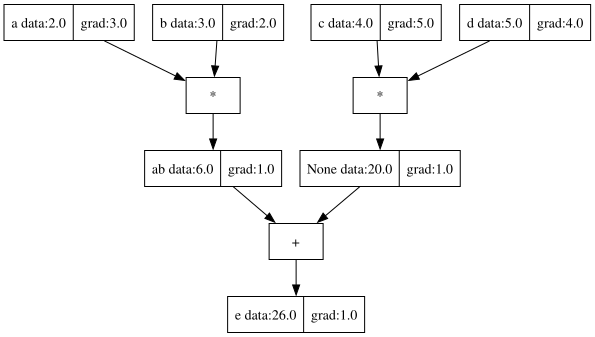

In [15]:
a=Value(2.0,label='a')
b=Value(3.0,label='b')
c=Value(4.0,label='c')
d=Value(5.0,label='d')

ab=a*b
ab.label='ab'
# ab.backward()
# ab.printGraph()
cd=c*d
e=ab+cd
e.label='e'
e.backward()
e.printGraph()

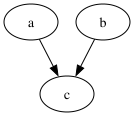

In [5]:
import graphviz

dot=graphviz.Digraph("test")

dot.node('a','a')
dot.node('b','b')
dot.node('c','c')

dot.edges(['ac','bc'])

dot